### **This file trains a model on the combined (RAVDESS, CREMA-D, TESS) dataset WITH data augmentation WITHOUT cross validation**

In [1]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Embedding, LSTM, BatchNormalization, GRU, Input, Flatten, Dropout, Activation, Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Model evaluation
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

import keras
from keras.preprocessing import sequence
from keras.preprocessing.sequence import pad_sequences

In [3]:
data_folder = 'datasets_combined_augmented'

# Paths to your previously saved files
X_train = np.load(f'../../{data_folder}/X_deep_train.npy', mmap_mode='r')
y_train = np.load(f'../../{data_folder}/y_deep_train.npy')
X_val = np.load(f'../../{data_folder}/X_deep_val.npy')
y_val = np.load(f'../../{data_folder}/y_deep_val.npy')
X_test = np.load(f'../../{data_folder}/X_deep_test.npy')
y_test = np.load(f'../../{data_folder}/y_deep_test.npy')

In [4]:
# Suppose y_train, y_val, y_test are like [1, 2, 3, 4, 5, 6, 7, 8]
# Convert them to zero-based index labels (required for to_categorical)
y_train_enc = y_train - 1
y_val_enc = y_val - 1
y_test_enc = y_test - 1

# Get number of classes automatically
num_classes = np.max(y_train_enc) + 1

# Convert to one-hot (instead of labels being a single integer, converts it to a binary vector)
# e.g. if happy = 2, it will be represented like this -> [0,1,0,0,0,0,0,0]
y_train_cat = to_categorical(y_train_enc, num_classes)
y_val_cat = to_categorical(y_val_enc, num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes)

# --- Get shape info for the model ---
time_steps = X_train.shape[1]
num_features = X_train.shape[2]

print(f"Time steps: {time_steps}, Num features: {num_features}, Classes: {num_classes}")

Time steps: 483, Num features: 92, Classes: 7


In [5]:
# --- Normalize features ---
# compute mean and sd from the train data
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

# standardize
X_train = (X_train - mean) / (std)
X_val = (X_val - mean) / (std)
X_test = (X_test - mean) / (std)

In [9]:
classes, counts = np.unique(y_train, return_counts=True)
print(dict(zip(classes, counts)))

{np.int64(1): np.int64(3892), np.int64(2): np.int64(4052), np.int64(3): np.int64(4044), np.int64(4): np.int64(4052), np.int64(5): np.int64(4048), np.int64(6): np.int64(4052), np.int64(7): np.int64(1420)}


In [21]:
import tensorflow as tf
from tensorflow.keras import layers as L

# Input shape: (timesteps, features)
input_shape = (X_train.shape[1], X_train.shape[2])

model = tf.keras.Sequential([
    # --- CNN Block 1 ---
    L.Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=input_shape), # 128
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, strides=2, padding='same'),

    # --- CNN Block 2 ---
    L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'), # 128
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, strides=2, padding='same'),
    L.Dropout(0.2),

    # --- CNN Block 3 ---
    L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'), # 256
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, strides=2, padding='same'),
    L.Dropout(0.2),

    # --- BiLSTM Block ---
    L.Bidirectional(L.LSTM(128, return_sequences=False)), # 128
    L.Dropout(0.3),

    # --- Dense Block ---
    L.Dense(256, activation='relu'), # 256
    L.Dropout(0.3),
    L.Dense(128, activation='relu'), # 128

    # --- Output ---
    L.Dense(7, activation='softmax')  # 7 emotion classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 483, 128)       │        59,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 483, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 242, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 242, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 242, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 121, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 121, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 121, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 121, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 61, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 61, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702,727 (2.68 MB)

 Trainable params: 701,703 (2.68 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [22]:
callbacks = [
    EarlyStopping(
        patience=10,                # stop if val_loss doesn't improve for 10 epochs
        restore_best_weights=True   # revert to best model
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',    # file to save the best model
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

In [23]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,             # upper limit — early stopping will likely end before this
    batch_size=64,         # number of samples per gradient update
    callbacks=callbacks,
    verbose=1,
    class_weight=class_weights
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 161s 375ms/step - accuracy: 0.4667 - loss: 1.2452 - val_accuracy: 0.5631 - val_loss: 1.0919 - learning_rate: 0.0010
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 142s 354ms/step - accuracy: 0.5935 - loss: 0.9710 - val_accuracy: 0.6006 - val_loss: 1.0335 - learning_rate: 0.0010
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 139s 348ms/step - accuracy: 0.6528 - loss: 0.8406 - val_accuracy: 0.6360 - val_loss: 0.9450 - learning_rate: 0.0010
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 140s 351ms/step - accuracy: 0.6990 - loss: 0.7429 - val_accuracy: 0.6523 - val_loss: 0.9105 - learning_rate: 0.0010
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 140s 350ms/step - accuracy: 0.7360 - loss: 0.6608 - val_accuracy: 0.6737 - val_loss: 0.8748 - learning_rate: 0.0010
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 141s 352ms/step - accuracy: 0.7665 - loss: 0.5925 - val_accuracy: 0.6809 - val_loss: 0.8887 - learning_rate: 0.0010
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 141s 353ms/step - accura

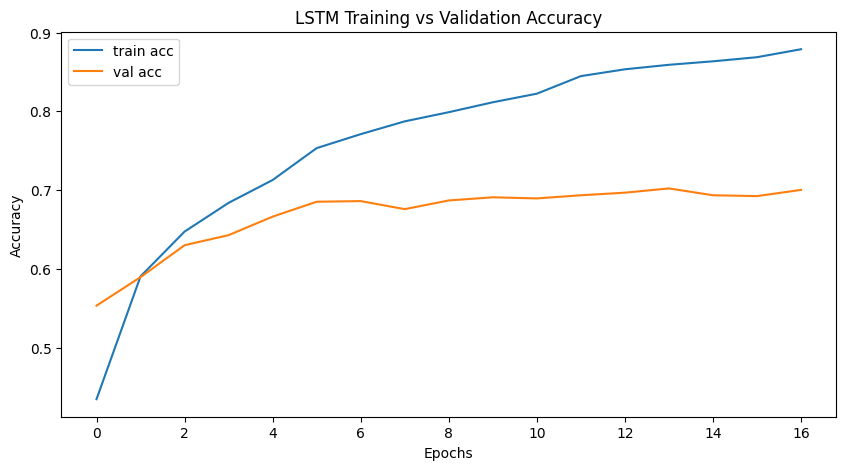

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Training vs Validation Accuracy')
plt.show()

### Evaluate model

In [24]:
from tensorflow.keras.models import load_model

# Load model
best_model = load_model('best_lstm_model.keras')

In [25]:
# Evaluate model on test
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=1)
print(f"Test Accuracy: {test_acc:.3f}, Test Loss: {test_loss:.3f}")

267/267 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.6885 - loss: 0.8483
Test Accuracy: 0.688, Test Loss: 0.848


In [27]:
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred_classes))


267/267 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step
              precision    recall  f1-score   support

           0       0.69      0.81      0.74      1296
           1       0.57      0.70      0.63      1352
           2       0.72      0.62      0.67      1348
           3       0.72      0.83      0.77      1352
           4       0.66      0.61      0.64      1352
           5       0.76      0.47      0.58      1348
           6       0.86      0.95      0.90       472

    accuracy                           0.69      8520
   macro avg       0.71      0.71      0.70      8520
weighted avg       0.70      0.69      0.68      8520

